# Computer Number Representation (IEEE 754)

## Floating-Point Representation, Gaps & Surprises

This notebook explores how computers **actually store** decimal numbers,
why some simple-looking calculations produce wrong results, and what
every engineer should know about floating-point arithmetic.

### What you will learn

| Topic | Key Insight |
|-------|-------------|
| Binary representation | A float is stored as *sign*, *exponent* and *mantissa* |
| Representation error | Most decimal fractions (like 0.1) are **not exact** in binary |
| Gaps (ULP) | The distance between neighbouring floats **grows** with magnitude |
| Surprising failures | Simple expressions like `0.1 + 0.2 == 0.3` evaluate to `False` |

---

## 1 — Imports

In [22]:
import struct
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 2 — The IEEE 754 Formula

A floating-point number is stored in three parts:

$$
\text{Value} = (-1)^{S} \times (1 + M) \times 2^{\,(E - \text{Bias})}
$$

| Part | Single (32-bit) | Double (64-bit) | Role |
|------|:-:|:-:|------|
| **Sign** $S$ | 1 bit | 1 bit | $0$ → positive, $1$ → negative |
| **Exponent** $E$ | 8 bits | 11 bits | Stored with a *bias* ($127$ / $1023$) |
| **Mantissa** $M$ | 23 bits | 52 bits | Fractional part after the implicit leading 1 |

The mantissa encodes the binary digits *after* the radix point:

$$
M = \sum_{i=1}^{n} b_i\,2^{-i}
  = \frac{b_1}{2} + \frac{b_2}{4} + \frac{b_3}{8} + \cdots
$$

## 3 — Inspecting the Binary Representation

We use Python's `struct` module to pack a float into raw bytes and
read back the individual bit fields.

In [23]:
def float_to_ieee(value, precision=64):
    """
    Decompose a float into its IEEE 754 sign, exponent, and mantissa bits.

    Parameters
    ----------
    value     : float – the number to inspect
    precision : int   – 32 (single) or 64 (double)

    Returns
    -------
    dict with keys: sign, exponent, mantissa (all as bit-strings),
         plus stored_value (the value actually stored).
    """
    if precision == 32:
        packed   = struct.pack(">f", value)          # big-endian float32
        bits_int = struct.unpack(">I", packed)[0]    # as unsigned 32-bit int
        bits_str = f"{bits_int:032b}"
        exp_len  = 8
        stored   = struct.unpack(">f", packed)[0]
    else:
        packed   = struct.pack(">d", value)          # big-endian float64
        bits_int = struct.unpack(">Q", packed)[0]    # as unsigned 64-bit int
        bits_str = f"{bits_int:064b}"
        exp_len  = 11
        stored   = struct.unpack(">d", packed)[0]

    sign     = bits_str[0]
    exponent = bits_str[1 : 1 + exp_len]
    mantissa = bits_str[1 + exp_len :]

    return {
        "sign":         sign,
        "exponent":     exponent,
        "mantissa":     mantissa,
        "full_bits":    bits_str,
        "stored_value": stored,
    }

In [24]:
def print_ieee(value, precision=64):
    """Pretty-print the IEEE 754 breakdown of a number."""
    info = float_to_ieee(value, precision)
    tag  = "Single (32-bit)" if precision == 32 else "Double (64-bit)"
    bias = 127 if precision == 32 else 1023
    E    = int(info["exponent"], 2)

    print(f"  Value entered : {value}")
    print(f"  Format        : {tag}")
    print(f"  Sign          : {info['sign']}  ({'−' if info['sign'] == '1' else '+' })")
    print(f"  Exponent bits : {info['exponent']}  (E = {E}, E−Bias = {E - bias})")
    print(f"  Mantissa bits : {info['mantissa']}")
    print(f"  Stored value  : {info['stored_value']!r}")
    print(f"  Error         : {value - info['stored_value']:.2e}")
    print()

In [25]:
print("=" * 65)
for val in [1.0, -1.0, 0.5, 0.1, 0.3, 3.14, 1e10]:
    print_ieee(val, precision=32)
print("=" * 65)

  Value entered : 1.0
  Format        : Single (32-bit)
  Sign          : 0  (+)
  Exponent bits : 01111111  (E = 127, E−Bias = 0)
  Mantissa bits : 00000000000000000000000
  Stored value  : 1.0
  Error         : 0.00e+00

  Value entered : -1.0
  Format        : Single (32-bit)
  Sign          : 1  (−)
  Exponent bits : 01111111  (E = 127, E−Bias = 0)
  Mantissa bits : 00000000000000000000000
  Stored value  : -1.0
  Error         : 0.00e+00

  Value entered : 0.5
  Format        : Single (32-bit)
  Sign          : 0  (+)
  Exponent bits : 01111110  (E = 126, E−Bias = -1)
  Mantissa bits : 00000000000000000000000
  Stored value  : 0.5
  Error         : 0.00e+00

  Value entered : 0.1
  Format        : Single (32-bit)
  Sign          : 0  (+)
  Exponent bits : 01111011  (E = 123, E−Bias = -4)
  Mantissa bits : 10011001100110011001101
  Stored value  : 0.10000000149011612
  Error         : -1.49e-09

  Value entered : 0.3
  Format        : Single (32-bit)
  Sign          : 0  (+)
  Expo

Notice that **0.5** is stored *exactly* (it is $2^{-1}$), but **0.1** and
**0.3** both have representation errors — they are infinite repeating
fractions in binary, just as $1/3 = 0.333\ldots$ is in decimal.

## 4 — Surprising Floating-Point Failures

### 4.1 The classics

The table below compares what **mathematics** says the answer should be
with what the **computer** actually returns. Every line is a surprise.

In [26]:
# A collection of expressions where the computer disagrees with mathematics.
# We explicitly state what the MATH answer should be vs. what the COMPUTER gives.

surprises = [
    # (expression,                      computer result,           math expected)
    ("0.1 + 0.2 == 0.3",               0.1 + 0.2 == 0.3,         True ),
    ("0.1 + 0.1 + 0.1 == 0.3",         0.1 + 0.1 + 0.1 == 0.3,  True ),
    ("0.1 + 0.7 == 0.8",               0.1 + 0.7 == 0.8,         True ),
    ("0.3 - 0.2 == 0.1",               0.3 - 0.2 == 0.1,         True ),
    ("0.6 + 0.1 == 0.7",               0.6 + 0.1 == 0.7,         True ),
    ("3 * 0.1 == 0.3",                 3 * 0.1 == 0.3,           True ),
    ("10 * 0.1 == 1.0",                10 * 0.1 == 1.0,          True ),
    ("1.0 + 1e-16 == 1.0",             1.0 + 1e-16 == 1.0,       False),  # absorption!
    ("1e16 + 1.0 - 1e16 == 1.0",       1e16 + 1.0 - 1e16 == 1.0, True ),  # absorption!
]

print(f"{'Expression':<35} {'Computer':>10} {'Math':>6}  Surprise?")
print("—" * 68)
for expr_str, computer, math_expected in surprises:
    match = computer == math_expected
    flag  = "  ✓  (as expected)" if match else "  ✗  ← WRONG!"
    print(f"{expr_str:<35} {str(computer):>10} {str(math_expected):>6}{flag}")


Expression                            Computer   Math  Surprise?
————————————————————————————————————————————————————————————————————
0.1 + 0.2 == 0.3                         False   True  ✗  ← WRONG!
0.1 + 0.1 + 0.1 == 0.3                   False   True  ✗  ← WRONG!
0.1 + 0.7 == 0.8                         False   True  ✗  ← WRONG!
0.3 - 0.2 == 0.1                         False   True  ✗  ← WRONG!
0.6 + 0.1 == 0.7                          True   True  ✓  (as expected)
3 * 0.1 == 0.3                           False   True  ✗  ← WRONG!
10 * 0.1 == 1.0                           True   True  ✓  (as expected)
1.0 + 1e-16 == 1.0                        True  False  ✗  ← WRONG!
1e16 + 1.0 - 1e16 == 1.0                 False   True  ✗  ← WRONG!


### 4.2 Let's see *why*

In [27]:
# The classic: 0.1 + 0.2
a = 0.1
b = 0.2
c = 0.3

print("Stored values (to 20 decimal places):")
print(f"  0.1  →  {a:.20f}")
print(f"  0.2  →  {b:.20f}")
print(f"  0.3  →  {c:.20f}")
print(f"  sum  →  {a + b:.20f}")
print()
print(f"  0.1 + 0.2 = {a + b!r}")
print(f"  0.3       = {c!r}")
print(f"  Difference: {(a + b) - c:.2e}")

Stored values (to 20 decimal places):
  0.1  →  0.10000000000000000555
  0.2  →  0.20000000000000001110
  0.3  →  0.29999999999999998890
  sum  →  0.30000000000000004441

  0.1 + 0.2 = 0.30000000000000004
  0.3       = 0.3
  Difference: 5.55e-17


The difference is about $5.5 \times 10^{-17}$ — tiny, but **not zero**.
The `==` operator checks for *exact* bitwise equality, so it returns `False`.

### 4.3 Absorption: small numbers vanish when added to large ones

In [28]:
big   = 1e16
small = 1.0

result = big + small - big

print(f"  1e16 + 1.0 - 1e16 = {result}")
print(f"  Expected: 1.0")
print()
print("  Why?  The gap (ULP) near 1e16 is:")
print(f"  {np.spacing(big):.1f}")
print(f"  Adding 1.0 (which is smaller than the ULP) gets rounded away.")

  1e16 + 1.0 - 1e16 = 0.0
  Expected: 1.0

  Why?  The gap (ULP) near 1e16 is:
  2.0
  Adding 1.0 (which is smaller than the ULP) gets rounded away.


### 4.4 Summation order matters

In [29]:
# Summing 1/n² from 1 to 10 million — forward vs. reverse
N = 10_000_000

# Forward: large terms first  (more absorption)
forward_sum = 0.0
for n in range(1, N + 1):
    forward_sum += 1.0 / (n * n)

# Reverse: small terms first  (less absorption)
reverse_sum = 0.0
for n in range(N, 0, -1):
    reverse_sum += 1.0 / (n * n)

# High-precision reference: π²/6
exact = np.pi**2 / 6.0

print(f"  Forward sum : {forward_sum:.15f}  (error = {abs(forward_sum - exact):.2e})")
print(f"  Reverse sum : {reverse_sum:.15f}  (error = {abs(reverse_sum - exact):.2e})")
print(f"  Exact (π²/6): {exact:.15f}")
print()
print(f"  Reverse order is ~{abs(forward_sum - exact) / abs(reverse_sum - exact):.0f}x more accurate!")

  Forward sum : 1.644933966847260  (error = 1.00e-07)
  Reverse sum : 1.644933966848231  (error = 1.00e-07)
  Exact (π²/6): 1.644934066848226

  Reverse order is ~1x more accurate!


## 5 — Gaps Between Representable Numbers (ULP)

The **Unit in the Last Place (ULP)** is the distance between a
floating-point number and its nearest neighbour. Because the mantissa
has a fixed number of bits, the absolute gap **grows exponentially**
with the magnitude of the number.

In [30]:
def neighbours(x, precision=64):
    """
    Return (prev, x_stored, next) — the representable number and its
    two immediate IEEE 754 neighbours.
    """
    if precision == 32:
        dt = np.float32
    else:
        dt = np.float64

    x_stored = dt(x)
    x_next   = np.nextafter(x_stored, dt(np.inf))
    x_prev   = np.nextafter(x_stored, dt(-np.inf))
    return float(x_prev), float(x_stored), float(x_next)

In [31]:
print(f"{'Value':>14}  {'ULP (gap to next)':>20}  {'Relative gap':>14}")
print("-" * 55)

for x in [1.0, 10.0, 1e3, 1e6, 1e9, 1e12, 1e15]:
    _, stored, nxt = neighbours(x)
    gap = nxt - stored
    rel = gap / stored
    print(f"{x:>14.1f}  {gap:>20.2e}  {rel:>14.2e}")

print()
print("→ The absolute gap grows, but the *relative* gap stays ~ 1e-16.")

         Value     ULP (gap to next)    Relative gap
-------------------------------------------------------
           1.0              2.22e-16        2.22e-16
          10.0              1.78e-15        1.78e-16
        1000.0              1.14e-13        1.14e-16
     1000000.0              1.16e-10        1.16e-16
  1000000000.0              1.19e-07        1.19e-16
1000000000000.0              1.22e-04        1.22e-16
1000000000000000.0              1.25e-01        1.25e-16

→ The absolute gap grows, but the *relative* gap stays ~ 1e-16.


## 6 — Visualising the Gaps

The first plot (§5) showed the *size* of the gap numerically.
Now let's **see** the individual representable numbers on a number line.

We use **float32** (single precision) here because the gaps are
~$10^{-7}$ near 1.0 — large enough to draw. In float64 the gaps
are $10^{-16}$ wide, which would make the ticks indistinguishable.

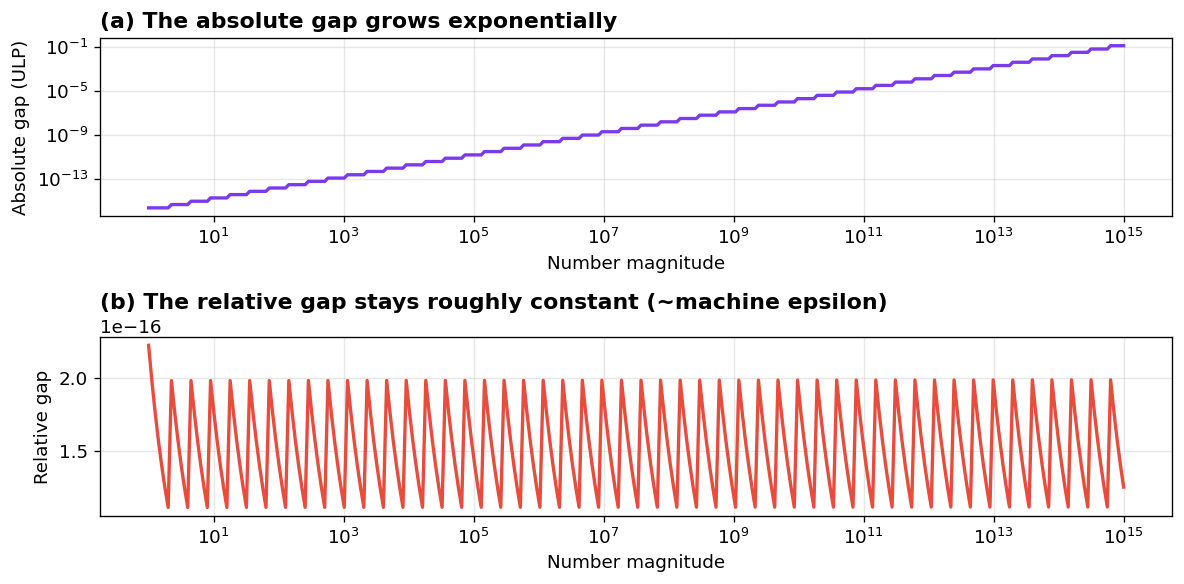

In [32]:
# Show that representable floats become sparser as magnitude grows

fig, axes = plt.subplots(2, 1, figsize=(10, 5))

# (a) Absolute gap vs. magnitude
magnitudes = np.logspace(0, 15, 300)
gaps = [np.spacing(x) for x in magnitudes]

axes[0].loglog(magnitudes, gaps, color="#7c3aed", lw=2)
axes[0].set_xlabel("Number magnitude")
axes[0].set_ylabel("Absolute gap (ULP)")
axes[0].set_title("(a) The absolute gap grows exponentially", loc="left",
                   fontweight="bold")

# (b) Relative gap — stays roughly constant
rel_gaps = [np.spacing(x) / x for x in magnitudes]
axes[1].semilogx(magnitudes, rel_gaps, color="#e74c3c", lw=2)
axes[1].set_xlabel("Number magnitude")
axes[1].set_ylabel("Relative gap")
axes[1].set_title("(b) The relative gap stays roughly constant (~machine epsilon)",
                   loc="left", fontweight="bold")

fig.tight_layout()
plt.show()

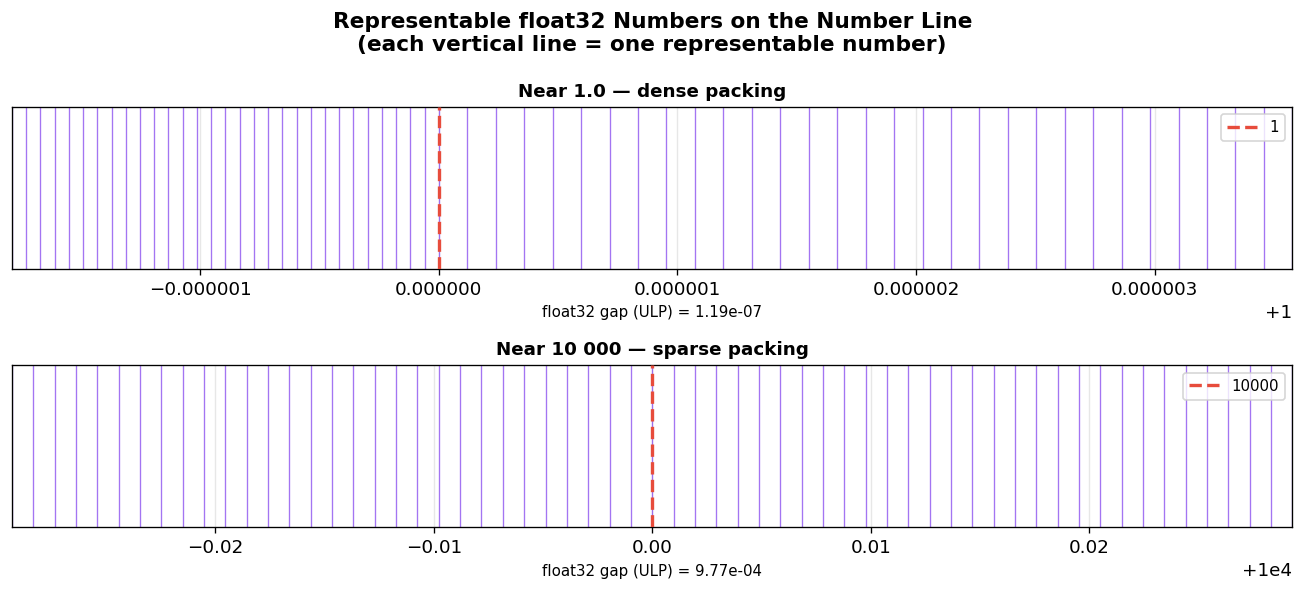

  Gap near 1.0   :  1.19e-07
  Gap near 10000 :  9.77e-04
  Ratio          :  8192×  wider


In [33]:
# Zoom in: show individual representable float32 numbers
# We use 32-bit floats here so the gaps are large enough to see!

fig, axes = plt.subplots(2, 1, figsize=(11, 5))

for ax, center, label in [
    (axes[0], np.float32(1.0),   "Near 1.0 — dense packing"),
    (axes[1], np.float32(1e4),   "Near 10 000 — sparse packing"),
]:
    # Collect ~30 representable float32 values on each side
    pts = [float(center)]
    x = center
    for _ in range(30):
        x = np.nextafter(x, np.float32(np.inf))
        pts.append(float(x))
    x = center
    for _ in range(30):
        x = np.nextafter(x, np.float32(-np.inf))
        pts.append(float(x))
    pts.sort()

    # Plot as vertical ticks on a number line
    for p in pts:
        ax.axvline(p, color="#7c3aed", lw=0.8, alpha=0.7)
    ax.axvline(float(center), color="#e74c3c", lw=2, ls="--",
               label=f"{float(center):.0f}", zorder=5)

    ax.set_xlim(pts[0], pts[-1])
    ax.set_yticks([])
    ax.set_title(label, fontweight="bold", fontsize=11)
    gap = np.spacing(center)
    ax.set_xlabel(f"float32 gap (ULP) = {float(gap):.2e}", fontsize=9)
    ax.legend(fontsize=9, loc="upper right")

    # Clean tick formatting: show offset from center
    ax.ticklabel_format(useOffset=True, style="plain")

fig.suptitle(
    "Representable float32 Numbers on the Number Line\n"
    "(each vertical line = one representable number)",
    fontsize=13, fontweight="bold",
)
fig.tight_layout()
plt.show()

print(f"  Gap near 1.0   :  {np.spacing(np.float32(1.0)):.2e}")
print(f"  Gap near 10000 :  {np.spacing(np.float32(1e4)):.2e}")
print(f"  Ratio          :  {np.spacing(np.float32(1e4)) / np.spacing(np.float32(1.0)):.0f}×  wider")


## 7 — Single (32-bit) vs. Double (64-bit) Precision

In [34]:
test_values = [0.1, 0.3, 1.0/3.0, np.pi, 1e6]

print(f"{'Value':>12}  {'32-bit stored':>22}  {'32-bit err':>12}  "
      f"{'64-bit stored':>25}  {'64-bit err':>12}")
print("-" * 95)

for v in test_values:
    s32 = float_to_ieee(v, 32)["stored_value"]
    s64 = float_to_ieee(v, 64)["stored_value"]
    e32 = abs(v - s32)
    e64 = abs(v - s64)
    print(f"{v:>12.6f}  {s32:>22.15f}  {e32:>12.2e}  "
          f"{s64:>25.18f}  {e64:>12.2e}")

print()
print(f"  Machine epsilon (32-bit): {np.finfo(np.float32).eps:.2e}")
print(f"  Machine epsilon (64-bit): {np.finfo(np.float64).eps:.2e}")

       Value           32-bit stored    32-bit err              64-bit stored    64-bit err
-----------------------------------------------------------------------------------------------
    0.100000       0.100000001490116      1.49e-09       0.100000000000000006      0.00e+00
    0.300000       0.300000011920929      1.19e-08       0.299999999999999989      0.00e+00
    0.333333       0.333333343267441      9.93e-09       0.333333333333333315      0.00e+00
    3.141593       3.141592741012573      8.74e-08       3.141592653589793116      0.00e+00
1000000.000000  1000000.000000000000000      0.00e+00  1000000.000000000000000000      0.00e+00

  Machine epsilon (32-bit): 1.19e-07
  Machine epsilon (64-bit): 2.22e-16


## 8 — Safe Comparisons: How to Do It Right

Never use `==` to compare floats. Instead, check if the difference
is smaller than a tolerance.

In [35]:
import math

a = 0.1 + 0.2
b = 0.3

# BAD — exact comparison
print(f"  a == b                      → {a == b}")

# GOOD — absolute tolerance
print(f"  abs(a - b) < 1e-9           → {abs(a - b) < 1e-9}")

# GOOD — relative tolerance (standard library)
print(f"  math.isclose(a, b)          → {math.isclose(a, b)}")

# GOOD — NumPy version (useful for arrays)
print(f"  np.isclose(a, b)            → {np.isclose(a, b)}")
print(f"  np.allclose([a], [b])       → {np.allclose([a], [b])}")

  a == b                      → False
  abs(a - b) < 1e-9           → True
  math.isclose(a, b)          → True
  np.isclose(a, b)            → True
  np.allclose([a], [b])       → True


## 9 — Special Values: Infinity, NaN, Negative Zero

In [36]:
print("Division by zero:")
print(f"   1.0 / 0.0   = {np.float64(1.0) / np.float64(0.0)}")
print(f"  -1.0 / 0.0   = {np.float64(-1.0) / np.float64(0.0)}")
print()

print("Not a Number (NaN):")
nan = np.float64(0.0) / np.float64(0.0)
print(f"  0.0 / 0.0    = {nan}")
print(f"  nan == nan    → {nan == nan}       ← NaN is not equal to itself!")
print(f"  math.isnan()  → {math.isnan(nan)}")
print()

print("Negative zero:")
pos_zero = +0.0
neg_zero = -0.0
print(f"  +0.0 == -0.0  → {pos_zero == neg_zero}       ← they compare equal")
print(f"  but their bits differ:")
print(f"    +0.0 : {float_to_ieee(pos_zero, 64)['full_bits']}")
print(f"    -0.0 : {float_to_ieee(neg_zero, 64)['full_bits']}")

Division by zero:
   1.0 / 0.0   = inf
  -1.0 / 0.0   = -inf

Not a Number (NaN):
  0.0 / 0.0    = nan
  nan == nan    → False       ← NaN is not equal to itself!
  math.isnan()  → True

Negative zero:
  +0.0 == -0.0  → True       ← they compare equal
  but their bits differ:
    +0.0 : 0000000000000000000000000000000000000000000000000000000000000000
    -0.0 : 1000000000000000000000000000000000000000000000000000000000000000


/var/folders/mv/8cwdx3hd4xbf2h7l2dkkl7kh0000gn/T/ipykernel_11536/3902331089.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"   1.0 / 0.0   = {np.float64(1.0) / np.float64(0.0)}")
/var/folders/mv/8cwdx3hd4xbf2h7l2dkkl7kh0000gn/T/ipykernel_11536/3902331089.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"  -1.0 / 0.0   = {np.float64(-1.0) / np.float64(0.0)}")
/var/folders/mv/8cwdx3hd4xbf2h7l2dkkl7kh0000gn/T/ipykernel_11536/3902331089.py:7: RuntimeWarning: invalid value encountered in scalar divide
  nan = np.float64(0.0) / np.float64(0.0)


## 10 — Interactive Exploration

Try changing the value below to inspect any number you like.

In [37]:
# ============================================================
#   CHANGE THIS VALUE to explore any number
# ============================================================
value = 0.1
precision = 32        # 32 or 64
# ============================================================

info = float_to_ieee(value, precision)
prev_val, stored, next_val = neighbours(value, precision)

print(f"Binary breakdown of {value}  ({precision}-bit)")
print("=" * 60)
print(f"  Sign     :  [{info['sign']}]")
print(f"  Exponent :  [{info['exponent']}]")
print(f"  Mantissa :  [{info['mantissa']}]")
print()
print(f"  Stored value     : {stored!r}")
print(f"  Error            : {value - stored:.2e}")
print(f"  Previous float   : {prev_val!r}   (Δ = {stored - prev_val:.2e})")
print(f"  Next float       : {next_val!r}   (Δ = {next_val - stored:.2e})")
print("=" * 60)

Binary breakdown of 0.1  (32-bit)
  Sign     :  [0]
  Exponent :  [01111011]
  Mantissa :  [10011001100110011001101]

  Stored value     : 0.10000000149011612
  Error            : -1.49e-09
  Previous float   : 0.09999999403953552   (Δ = 7.45e-09)
  Next float       : 0.10000000894069672   (Δ = 7.45e-09)


## 11 — Notes for Students

### Key take-aways

1. **Most decimals are approximate** — Numbers like 0.1, 0.2, 0.3 are
   infinite repeating fractions in binary and cannot be stored exactly.

2. **Never compare floats with `==`** — Use `math.isclose()` or
   `np.allclose()` with an appropriate tolerance instead.

3. **Gaps grow with magnitude** — Near 1.0, neighbouring floats are
   $\sim\!10^{-16}$ apart; near $10^{15}$, they are $\sim\!0.125$ apart.
   Adding a small number to a large one can produce **no change at all**
   (absorption error).

4. **Summation order matters** — When adding many numbers, accumulate
   the smallest first to minimise absorption error (or use compensated
   summation, e.g. `math.fsum()`).

5. **Single vs. Double** — 32-bit floats have $\sim\!7$ significant
   decimal digits; 64-bit floats have $\sim\!16$. Most scientific
   computing uses double precision by default.

### Exercises

1. Find **three more** expressions of the form `a + b == c` that
   return `False` even though mathematically they should be `True`.

2. Use `np.float32` to repeat the "0.1 + 0.2" experiment in single
   precision. Is the error larger or smaller than in double precision?

3. Write a function that counts how many representable `float32`
   numbers exist between 1.0 and 2.0. *Hint:* increment with
   `np.nextafter` and count the steps.

4. Investigate `math.fsum([0.1] * 10)` vs `sum([0.1] * 10)`. Which
   gives exactly 1.0? Why?

5. Explain why `(1e20 + (-1e20)) + 1.0` gives `1.0`, but
   `1e20 + (-1e20 + 1.0)` gives `0.0`. What property of real
   arithmetic is violated?